<a href="https://colab.research.google.com/github/briskicedteaa/CFTR-Variant-Explorer/blob/main/notebooks/CFTR_Variant_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython
from Bio import SeqIO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 18.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_json("P13569.json")

count = df["features"].apply(lambda x: "begin" in x).sum()
count2 = df["features"].apply(lambda x: "wildType" in x).sum()
count3 = df["features"].apply(lambda x: "mutatedType" in x).sum()
count4 = df["features"].apply(lambda x: "consequenceType" in x).sum()
count5 = df["features"].apply(lambda x: "clinicalSignificances" in x).sum()
count6 = df["features"].apply(lambda x: "association" in x).sum()
print("Begin:", count,"wildType:", count2,"mutatedType:", count3,"consequenceType:", count4,"clinicalSignificances:", count5,"association:", count6)

Begin: 3664 wildType: 3664 mutatedType: 3216 consequenceType: 3664 clinicalSignificances: 2909 association: 2895


In [ ]:
variants = []

for feature in df["features"]:
  variants.append({
      "Position": int(feature["begin"]),
      "WildType": feature["wildType"],
      "MutatedType": feature.get("mutatedType"),
      "Consequence": feature["consequenceType"]
  })

variants_df = pd.DataFrame(variants)
variants_df["Position"].describe()
variants_df["Position"].nunique()
variants_df.head()

,Position,WildType,MutatedType,Consequence
0,1,M,None,initiator codon variant
1,1,M,I,missense
2,1,M,K,missense
3,1,M,R,missense
4,1,M,T,missense


In [ ]:
variants_df["Position"].value_counts().head(20)

,count
Position,
1098,8
508,8
137,8
311,7
14,7
17,7
1295,7
1023,7
1130,6


In [ ]:
variants_df["Consequence"].value_counts()

,count
Consequence,
missense,2809
frameshift,459
stop gained,316
inframe deletion,52
-,13
insertion,11
stop lost,3
initiator codon variant,1


In [ ]:
missense_df = variants_df[
    variants_df["Consequence"] == "missense"
].copy()

missense_df.shape

(2809, 4)

In [ ]:
position_variants = (
    variants_df.dropna(subset=["MutatedType"])
    .groupby("Position")["MutatedType"]
    .nunique()
    .sort_values(ascending=False)
)

position_variants.head(20)

,MutatedType
Position,
117,6
1098,6
192,6
317,6
579,6
530,6
506,6
508,6
1154,5


In [ ]:
!wget -q -O /usr/share/fonts/truetype/Humor-Sans.ttf https://github.com

import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import logging
from matplotlib.colors import LinearSegmentedColormap

mpl.font_manager._load_fontmanager(try_read_cache=False)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

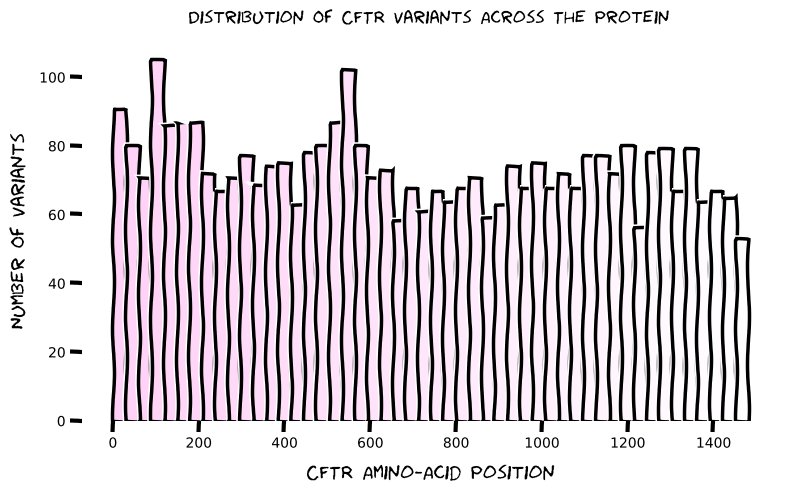

In [ ]:
textcolor = "#000000"
bgcolor = "#ffffff"
gridcolor = "#000000"

customgradient = LinearSegmentedColormap.from_list("pink_to_white", ["#ffd1f7", "#ffffff"])

mpl.rcParams['figure.facecolor'] = bgcolor
mpl.rcParams['axes.facecolor'] = bgcolor

with plt.xkcd():
  fig, ax = plt.subplots(figsize=(8, 5), facecolor=bgcolor)
  ax.set_facecolor(bgcolor)

  n, bins, patches = ax.hist(
      variants_df["Position"],
      bins=50,
      edgecolor='000000',
      alpha=1.0,
      linewidth=2.5,
      zorder=3
      )

  [patch.set_facecolor(customgradient(i / 50)) for i, patch in enumerate(patches)]

  plt.xlabel("CFTR Amino-Acid Position", weight='bold', labelpad=10, color=textcolor, fontname="Humor Sans")
  plt.ylabel("Number Of Variants", weight='bold', labelpad=10, color=textcolor, fontname="Humor Sans")
  plt.title("Distribution Of CFTR Variants Across The Protein", weight='bold', pad=15, color=textcolor, fontsize=13, fontname="Humor Sans")

  ax.tick_params(colors=textcolor, labelsize=10)
  ax.grid(axis='y', linestyle='-', alpha=1.0, color=gridcolor)

  for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
counts, edges, = pd.cut(
    variants_df["Position"],
    bins=50,
    retbins=True
)

bin_counts = counts.value_counts().sort_index()

m = bin_counts.reset_index()
hist_df = pd.DataFrame(m)

print(bin_counts)

Position
(-0.48, 30.6]        91
(30.6, 60.2]         80
(60.2, 89.8]         71
(89.8, 119.4]       105
(119.4, 149.0]       90
(149.0, 178.6]       83
(178.6, 208.2]       87
(208.2, 237.8]       72
(237.8, 267.4]       67
(267.4, 297.0]       75
(297.0, 326.6]       73
(326.6, 356.2]       69
(356.2, 385.8]       74
(385.8, 415.4]       75
(415.4, 445.0]       65
(445.0, 474.6]       76
(474.6, 504.2]       80
(504.2, 533.8]       87
(533.8, 563.4]      102
(563.4, 593.0]       81
(593.0, 622.6]       70
(622.6, 652.2]       73
(652.2, 681.8]       58
(681.8, 711.4]       68
(711.4, 741.0]       62
(741.0, 770.6]       66
(770.6, 800.2]       64
(800.2, 829.8]       68
(829.8, 859.4]       71
(859.4, 889.0]       61
(889.0, 918.6]       61
(918.6, 948.2]       74
(948.2, 977.8]       68
(977.8, 1007.4]      75
(1007.4, 1037.0]     69
(1037.0, 1066.6]     71
(1066.6, 1096.2]     68
(1096.2, 1125.8]     77
(1125.8, 1155.4]     77
(1155.4, 1185.0]     73
(1185.0, 1214.6]     79
(1214.6

In [ ]:
hist_df.columns = ["Position", "Variant_Count"]

hist_df.head()

,Position,Variant_Count
0,"(-0.48, 30.6]",91
1,"(30.6, 60.2]",80
2,"(60.2, 89.8]",71
3,"(89.8, 119.4]",105
4,"(119.4, 149.0]",90


In [ ]:
hist_df["Region"] = pd.cut(
    hist_df.index,
    bins=[-1, 16, 33, 50],
    labels=["N-terminal", "Middle", "C-terminal"]
)

hist_df

,Position,Variant_Count,Region
0,"(-0.48, 30.6]",91,N-terminal
1,"(30.6, 60.2]",80,N-terminal
2,"(60.2, 89.8]",71,N-terminal
3,"(89.8, 119.4]",105,N-terminal
4,"(119.4, 149.0]",90,N-terminal
5,"(149.0, 178.6]",83,N-terminal
6,"(178.6, 208.2]",87,N-terminal
7,"(208.2, 237.8]",72,N-terminal
8,"(237.8, 267.4]",67,N-terminal
9,"(267.4, 297.0]",75,N-terminal


In [ ]:
regional_avg = (
    hist_df.groupby("Region", observed = True)["Variant_Count"]
    .mean()
)

regional_stats = (
    hist_df.groupby("Region", observed = True)["Variant_Count"]
    .agg(["mean", "median", "min", "max"])
)

print("Averages:", regional_avg)
print("Stats:", regional_stats)

Averages: Region
N-terminal    78.411765
Middle        71.117647
C-terminal    70.125000
Name: Variant_Count, dtype: float64
Stats:                  mean  median  min  max
Region                                 
N-terminal  78.411765    75.0   65  105
Middle      71.117647    68.0   58  102
C-terminal  70.125000    70.0   53   79


In [ ]:
hist_df.sort_values(
    "Variant_Count",
    ascending=False
).head(10)

,Position,Variant_Count,Region
3,"(89.8, 119.4]",105,N-terminal
18,"(533.8, 563.4]",102,Middle
0,"(-0.48, 30.6]",91,N-terminal
4,"(119.4, 149.0]",90,N-terminal
17,"(504.2, 533.8]",87,Middle
6,"(178.6, 208.2]",87,N-terminal
5,"(149.0, 178.6]",83,N-terminal
19,"(563.4, 593.0]",81,Middle
1,"(30.6, 60.2]",80,N-terminal
16,"(474.6, 504.2]",80,N-terminal


In [ ]:
variants_df["Region"] = pd.cut(
    variants_df["Position"],
    bins=[0, 493, 986, 1480],
    labels=["N-terminal", "Middle", "C-terminal"]
)

variants_df

,Position,WildType,MutatedType,Consequence,Region
0,1,M,None,initiator codon variant,N-terminal
1,1,M,I,missense,N-terminal
2,1,M,K,missense,N-terminal
3,1,M,R,missense,N-terminal
4,1,M,T,missense,N-terminal
...,...,...,...,...,...
3659,1478,T,R,missense,C-terminal
3660,1479,R,K,missense,C-terminal
3661,1480,L,P,missense,C-terminal
3662,1481,*,Q,stop lost,NaN


In [ ]:
variant_region_counts = pd.crosstab(
    variants_df["Region"],
    variants_df["Consequence"]
)

variant_region_percent = pd.crosstab(
    variants_df["Region"],
    variants_df["Consequence"],
    normalize="index"
) * 100

print("Region Counts:", variant_region_counts)
print("Region Percent:", variant_region_percent.round(2))

Region Counts: Consequence  -  frameshift  inframe deletion  initiator codon variant  \
Region                                                                  
N-terminal   6         170                17                        1   
Middle       6         143                15                        0   
C-terminal   1         146                20                        0   

Consequence  insertion  missense  stop gained  stop lost  
Region                                                    
N-terminal           6       990          110          0  
Middle               1       921          107          0  
C-terminal           4       898           99          1  
Region Percent: Consequence     -  frameshift  inframe deletion  initiator codon variant  \
Region                                                                     
N-terminal   0.46       13.08              1.31                     0.08   
Middle       0.50       11.99              1.26                     0.00   
C-te

In [ ]:
substitution_counts = (
    variants_df[
        variants_df["Consequence"] == "missense"
    ]
    .groupby(["WildType", "MutatedType"])
    .size()
    .sort_values(ascending=False)
)

print(substitution_counts.head(20))

WildType  MutatedType
I         V              77
L         F              67
F         L              65
L         P              57
I         T              55
A         V              53
L         V              46
A         T              45
G         R              44
E         K              42
T         I              39
V         L              38
K         E              38
G         V              35
R         G              35
V         I              35
T         A              35
S         R              33
G         E              33
V         A              33
dtype: int64


In [ ]:
!pip install BioPython
from Bio import SeqIO

In [120]:
import gzip

with gzip.open("uniprotkb_CFTR_2026_08_24.fasta.gz", "rt") as handle:
  records = list(SeqIO.parse(handle, "fasta"))

SeqIO.write(records, "CFTR_Homologs.fasta", "fasta")

15201

In [121]:
for record in SeqIO.parse("CFTR_Homologs.fasta", "fasta"):
    print(f"Description: {record.description}")

Streaming output truncated to the last 5000 lines.
Description: tr|A0A8C5KSY1|A0A8C5KSY1_JACJA Adhesion G-protein coupled receptor G2 OS=Jaculus jaculus OX=51337 GN=Adgrg2 PE=3 SV=1
Description: tr|A0A8C5KTN6|A0A8C5KTN6_JACJA Adhesion G-protein coupled receptor G2 OS=Jaculus jaculus OX=51337 GN=Adgrg2 PE=3 SV=1
Description: tr|A0A8C5KU86|A0A8C5KU86_JACJA Exportin-2 OS=Jaculus jaculus OX=51337 GN=Cse1l PE=3 SV=1
Description: tr|A0A8C5KY65|A0A8C5KY65_JACJA ATP-binding cassette, sub-family C member 8 OS=Jaculus jaculus OX=51337 GN=Abcc8 PE=3 SV=1
Description: tr|A0A8C5L5N7|A0A8C5L5N7_JACJA ABC transporter domain-containing protein OS=Jaculus jaculus OX=51337 PE=3 SV=1
Description: tr|A0A8C5L7Z9|A0A8C5L7Z9_JACJA ABC transporter domain-containing protein OS=Jaculus jaculus OX=51337 PE=3 SV=1
Description: tr|A0A8C5LDP6|A0A8C5LDP6_JACJA ABC transmembrane type-1 domain-containing protein OS=Jaculus jaculus OX=51337 PE=4 SV=1
Description: tr|A0A8C5LU58|A0A8C5LU58_9ANUR Adhesion G-protein couple

In [122]:
import pandas as pd

# Created df and added columns

df = pd.DataFrame({
    "ID": [record.id for record in records],
    "Description": [record.description for record in records],
    "Sequence": [str(record.seq) for record in records],
    "Length": [len(record.seq) for record in records],
})

# Filtering for only CFTR in description column

CFTR_df = df[
    df["Description"].str.contains(
        "Cystic fibrosis transmembrane conductance regulator",
        case=False,
        na=False
    )
].copy()

# Removed proteins containing "Fragment" in description

CFTR_df = CFTR_df[
    ~CFTR_df["Description"].str.contains(
        "Fragment",
        case=False,
        na=False
    )
].copy()

# Dropped duplicates

CFTR_df = CFTR_df.drop_duplicates(
    subset="Sequence",
    keep="first"

).copy()

print("Remaining Proteins:", len(CFTR_df))
print("Total Proteins:", len(df))
print("Duplicate sequences:", len(CFTR_df) - CFTR_df["Sequence"].nunique())
df.head()

Remaining Proteins: 1649
Total Proteins: 15201
Duplicate sequences: 0


,ID,Description,Sequence,Length
0,tr|A0A087Y0E6|A0A087Y0E6_POEFO,tr|A0A087Y0E6|A0A087Y0E6_POEFO Cystic fibrosis...,MEKVRKDGKKNPAATANILSKIFFWWLNPLFRIGYKRRLEEEDMYE...,1322
1,tr|A0A091E3B6|A0A091E3B6_FUKDA,tr|A0A091E3B6|A0A091E3B6_FUKDA Cystic fibrosis...,MYSVLPQDRSKYLGEELQGYWDREVLRAEKDTRKPSLTKAIIKCYW...,1311
2,tr|A0A0G2K3B1|A0A0G2K3B1_RAT,tr|A0A0G2K3B1|A0A0G2K3B1_RAT Cystic fibrosis t...,MDLEKLTGGGGGRKEEEREEKGEQSEGKDSVGEGREREEGGEREEG...,1665
3,sp|A0A0H2ZD27|CIF_PSEAB,sp|A0A0H2ZD27|CIF_PSEAB CFTR inhibitory factor...,MILDRLCRGLLAGIALTFSLGGFAAEEFPVPNGFESAYREVDGVKL...,319
4,tr|A0A0U3J5G9|A0A0U3J5G9_ORYME,tr|A0A0U3J5G9|A0A0U3J5G9_ORYME Cystic fibrosis...,MEKVGKNNPAATANIFSKIFFWWLNPLFRIGSKRRLDEDDMFEVLP...,1324


In [124]:
CFTR_df[
    ["ID", "Description", "Length"]
].sort_values("Length").head(30)

# Dropped proteins below 1400 AA

CFTR_df = CFTR_df[
    CFTR_df["Length"] >= 1400
].copy()

print("Proteins remaining:", len(CFTR_df))
print("Below 1400 aa:", (CFTR_df["Length"] < 1400).sum())
print("1400 aa or longer:", (CFTR_df["Length"] >= 1400).sum())
CFTR_df["Length"].describe()

Proteins remaining: 1008
Below 1400 aa: 0
1400 aa or longer: 1008


,Length
count,1008.000000
mean,1474.126984
std,38.861168
min,1400.000000
25%,1454.000000
50%,1480.000000
75%,1488.000000
max,1750.000000


In [126]:
from google.colab import files

with open("CFTR_Homologs.fasta", "w") as f:
    for _, row in CFTR_df.iterrows():
        f.write(f">{row['ID']}\n")
        f.write(f"{row['Sequence']}\n")

files.download("CFTR_Homologs.fasta")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>